In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [7]:
print("Missing values:\n")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0


In [8]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [9]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month Name"] = df["Order Date"].dt.strftime("%B")

df[["Order Date", "Year", "Month", "Month Name"]].head()

,Order Date,Year,Month,Month Name
0,2016-11-08,2016,11,November
1,2016-11-08,2016,11,November
2,2016-06-12,2016,6,June
3,2015-10-11,2015,10,October
4,2015-10-11,2015,10,October


In [10]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
avg_order_value = total_sales / total_orders

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value, 2))

Total Sales: 2297200.86
Total Profit: 286397.02
Total Orders: 5009
Average Order Value: 458.61


In [11]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [12]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [13]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [31]:
loss_products = df[df["Profit"] < 0]
print("Loss making rows:", loss_products.shape[0])

loss_products[["Product Name", "Category", "Sub-Category", "Sales", "Discount", "Profit"]].head(20)

Loss making rows: 1871


,Product Name,Category,Sub-Category,Sales,Discount,Profit
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,Tables,957.5775,0.45,-383.0310
14,Holmes Replacement Filter for HEPA Air Cleaner...,Office Supplies,Appliances,68.8100,0.80,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,Office Supplies,Binders,2.5440,0.80,-3.8160
23,"Global Deluxe Stacking Chair, Gray",Furniture,Chairs,71.3720,0.30,-1.0196
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,3083.4300,0.50,-1665.0522
28,Avery Recycled Flexi-View Covers for Binding S...,Office Supplies,Binders,9.6180,0.70,-7.0532
32,"Acco Pressboard Covers with Storage Hooks, 14 ...",Office Supplies,Binders,6.8580,0.70,-5.7150
36,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",Furniture,Furnishings,190.9200,0.60,-147.9630
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",Furniture,Bookcases,532.3992,0.32,-46.9764
39,"Global Fabric Manager's Chair, Dark Gray",Furniture,Chairs,212.0580,0.30,-15.1470


In [15]:
discount_analysis = df.groupby("Discount")[["Sales", "Profit"]].mean().sort_index()
discount_analysis

,Sales,Profit
Discount,,
0.00,226.742074,66.900292
0.10,578.397351,96.055074
0.15,529.971567,27.288298
0.20,209.076940,24.702572
0.30,454.742974,-45.679636
0.32,536.794770,-88.560656
0.40,565.134874,-111.927429
0.45,498.634000,-226.646464
0.50,892.705152,-310.703456


In [18]:
df["Profit Margin"] = np.where(df["Sales"] != 0, df["Profit"] / df["Sales"], 0)
df[["Sales", "Profit", "Profit Margin"]].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


In [19]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
monthly_sales.head(12)

,Year,Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [20]:
df.to_csv("cleaned_superstore.csv", index=False)
print("Cleaned file saved as cleaned_superstore.csv")

Cleaned file saved as cleaned_superstore.csv


In [21]:
high_sales_low_profit = df[(df["Sales"] > df["Sales"].quantile(0.75)) & (df["Profit"] < 0)]

high_sales_low_profit[["Product Name", "Category", "Sales", "Profit"]].head(10)

,Product Name,Category,Sales,Profit
3,Bretford CR4500 Series Slim Rectangular Table,Furniture,957.5775,-383.0310
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,3083.4300,-1665.0522
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",Furniture,532.3992,-46.9764
39,"Global Fabric Manager's Chair, Dark Gray",Furniture,212.0580,-15.1470
66,"Global Value Mid-Back Manager's Chair, Gray",Furniture,213.1150,-15.2225
72,High-Back Leather Manager's Chair,Furniture,831.9360,-114.3912
84,Safco Industrial Wire Shelving,Office Supplies,230.3760,-48.9549
103,Logitech K350 2.4Ghz Wireless Keyboard,Technology,238.8960,-26.8758
124,Global Deluxe High-Back Manager's Chair,Furniture,600.5580,-8.5794
125,Bevis 44 x 96 Conference Tables,Furniture,617.7000,-407.6820


In [22]:
top_profit_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
top_profit_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [23]:
worst_profit_products = df.groupby("Product Name")["Profit"].sum().sort_values().head(10)
worst_profit_products

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [24]:
discount_profit = df.groupby("Discount")[["Sales", "Profit"]].mean().reset_index()
discount_profit

,Discount,Sales,Profit
0,0.00,226.742074,66.900292
1,0.10,578.397351,96.055074
2,0.15,529.971567,27.288298
3,0.20,209.076940,24.702572
4,0.30,454.742974,-45.679636
5,0.32,536.794770,-88.560656
6,0.40,565.134874,-111.927429
7,0.45,498.634000,-226.646464
8,0.50,892.705152,-310.703456
9,0.60,48.150000,-43.077212


In [29]:
segment_perf = df.groupby("Segment")[["Sales", "Profit"]].sum().sort_values(by="Sales", ascending=False)
segment_perf
segment_perf = segment_perf.round(2)
segment_perf


,Sales,Profit
Segment,,
Consumer,1161401.34,134119.21
Corporate,706146.37,91979.13
Home Office,429653.15,60298.68


In [32]:
monthly_profit = df.groupby(["Year", "Month"])["Profit"].sum().reset_index()
monthly_profit.head(24)

,Year,Month,Profit
0,2014,1,2450.1907
1,2014,2,862.3084
2,2014,3,498.7299
3,2014,4,3488.8352
4,2014,5,2738.7096
5,2014,6,4976.5244
6,2014,7,-841.4826
7,2014,8,5318.1050
8,2014,9,8328.0994
9,2014,10,3448.2573


In [34]:
best_subcat = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending=False).head(1)
best_subcat

Sub-Category
Copiers    55617.8249
Name: Profit, dtype: float64

In [35]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2017-12-31 00:00:00')

In [36]:
rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,
    "Order ID": "nunique",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,185,5,5563.560
AA-10375,20,9,1056.390
AA-10480,260,4,1790.512
AA-10645,56,6,5086.935
AB-10015,416,3,886.156


In [37]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
Customer ID,,,,,,
AA-10315,185,5,5563.560,1,1,4
AA-10375,20,9,1056.390,4,4,1
AA-10480,260,4,1790.512,1,1,2
AA-10645,56,6,5086.935,3,2,4
AB-10015,416,3,886.156,1,1,1


In [38]:
rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
Customer ID,,,,,,,
AA-10315,185,5,5563.560,1,1,4,114
AA-10375,20,9,1056.390,4,4,1,441
AA-10480,260,4,1790.512,1,1,2,112
AA-10645,56,6,5086.935,3,2,4,324
AB-10015,416,3,886.156,1,1,1,111


In [39]:
def segment(row):
    if row["RFM_Score"] == "444":
        return "VIP Customers"
    elif row["F_score"] == 4:
        return "Loyal Customers"
    elif row["R_score"] == 1:
        return "At Risk"
    else:
        return "Regular"

rfm["Segment"] = rfm.apply(segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
Customer ID,,,,,,,,
AA-10315,185,5,5563.560,1,1,4,114,At Risk
AA-10375,20,9,1056.390,4,4,1,441,Loyal Customers
AA-10480,260,4,1790.512,1,1,2,112,At Risk
AA-10645,56,6,5086.935,3,2,4,324,Regular
AB-10015,416,3,886.156,1,1,1,111,At Risk


In [40]:
rfm["Segment"].value_counts()

Segment
Regular            419
At Risk            176
Loyal Customers    164
VIP Customers       34
Name: count, dtype: int64

In [44]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

segment_revenue.round(2)

Segment
Regular            1130760.20
Loyal Customers     606429.56
At Risk             360647.10
VIP Customers       199364.00
Name: Monetary, dtype: float64

In [45]:
monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()
monthly_sales.head()

,Year,Month,Sales
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


In [46]:
monthly_sales["Rolling_Mean"] = monthly_sales["Sales"].rolling(window=3).mean()
monthly_sales.head()

,Year,Month,Sales,Rolling_Mean
0,2014,1,14236.895,NaN
1,2014,2,4519.892,NaN
2,2014,3,55691.009,24815.932000
3,2014,4,28295.345,29502.082000
4,2014,5,23648.287,35878.213667


In [47]:
monthly_sales["Rolling_STD"] = monthly_sales["Sales"].rolling(window=3).std()
monthly_sales.head()

,Year,Month,Sales,Rolling_Mean,Rolling_STD
0,2014,1,14236.895,NaN,NaN
1,2014,2,4519.892,NaN,NaN
2,2014,3,55691.009,24815.932000,27176.420324
3,2014,4,28295.345,29502.082000,25606.892908
4,2014,5,23648.287,35878.213667,17314.991516


In [48]:
monthly_sales["Upper_Bound"] = monthly_sales["Rolling_Mean"] + 2 * monthly_sales["Rolling_STD"]
monthly_sales["Lower_Bound"] = monthly_sales["Rolling_Mean"] - 2 * monthly_sales["Rolling_STD"]

monthly_sales.head()

,Year,Month,Sales,Rolling_Mean,Rolling_STD,Upper_Bound,Lower_Bound
0,2014,1,14236.895,NaN,NaN,NaN,NaN
1,2014,2,4519.892,NaN,NaN,NaN,NaN
2,2014,3,55691.009,24815.932000,27176.420324,79168.772649,-29536.908649
3,2014,4,28295.345,29502.082000,25606.892908,80715.867816,-21711.703816
4,2014,5,23648.287,35878.213667,17314.991516,70508.196699,1248.230634


In [49]:
monthly_sales["Anomaly"] = (
    (monthly_sales["Sales"] > monthly_sales["Upper_Bound"]) |
    (monthly_sales["Sales"] < monthly_sales["Lower_Bound"])
)

monthly_sales.head()

,Year,Month,Sales,Rolling_Mean,Rolling_STD,Upper_Bound,Lower_Bound,Anomaly
0,2014,1,14236.895,NaN,NaN,NaN,NaN,False
1,2014,2,4519.892,NaN,NaN,NaN,NaN,False
2,2014,3,55691.009,24815.932000,27176.420324,79168.772649,-29536.908649,False
3,2014,4,28295.345,29502.082000,25606.892908,80715.867816,-21711.703816,False
4,2014,5,23648.287,35878.213667,17314.991516,70508.196699,1248.230634,False


In [50]:
anomalies = monthly_sales[monthly_sales["Anomaly"] == True]
anomalies

,Year,Month,Sales,Rolling_Mean,Rolling_STD,Upper_Bound,Lower_Bound,Anomaly


In [51]:
monthly_sales["Upper_Bound"] = monthly_sales["Rolling_Mean"] + 1 * monthly_sales["Rolling_STD"]
monthly_sales["Lower_Bound"] = monthly_sales["Rolling_Mean"] - 1 * monthly_sales["Rolling_STD"]

monthly_sales["Anomaly"] = (
    (monthly_sales["Sales"] > monthly_sales["Upper_Bound"]) |
    (monthly_sales["Sales"] < monthly_sales["Lower_Bound"])
)

anomalies = monthly_sales[monthly_sales["Anomaly"] == True]
anomalies

,Year,Month,Sales,Rolling_Mean,Rolling_STD,Upper_Bound,Lower_Bound,Anomaly
2,2014,3,55691.0090,24815.932000,27176.420324,51992.352324,-2360.488324,True
5,2014,6,34595.1276,28846.253200,5494.174612,34340.427812,23352.078588,True
7,2014,8,27909.4685,32150.329700,3686.989549,35837.319249,28463.340151,True
8,2014,9,81777.3508,47877.737433,29512.691408,77390.428842,18365.046025,True
12,2015,1,18174.0756,55449.470933,32599.340209,88048.811143,22850.130724,True
14,2015,3,38726.2520,22950.579533,14011.933129,36962.512662,8938.646404,True
17,2015,6,24797.2920,29708.062333,4713.258078,34421.320411,24994.804255,True
19,2015,8,36898.3322,30153.649733,6168.823036,36322.472770,23984.826697,True
20,2015,9,64595.9180,43419.858400,18784.450396,62204.308796,24635.408004,True
24,2016,1,18542.4910,56478.191900,32857.499549,89335.691449,23620.692351,True


In [53]:
forecast_data = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

# Date column bana do
forecast_data["Date"] = pd.to_datetime(forecast_data["Year"].astype(str) + "-" + forecast_data["Month"].astype(str))

forecast_data = forecast_data.sort_values("Date")
forecast_data.head()

,Year,Month,Sales,Date
0,2014,1,14236.895,2014-01-01
1,2014,2,4519.892,2014-02-01
2,2014,3,55691.009,2014-03-01
3,2014,4,28295.345,2014-04-01
4,2014,5,23648.287,2014-05-01


In [54]:
forecast_data["Forecast"] = forecast_data["Sales"].rolling(window=3).mean()
forecast_data.head()

,Year,Month,Sales,Date,Forecast
0,2014,1,14236.895,2014-01-01,NaN
1,2014,2,4519.892,2014-02-01,NaN
2,2014,3,55691.009,2014-03-01,24815.932000
3,2014,4,28295.345,2014-04-01,29502.082000
4,2014,5,23648.287,2014-05-01,35878.213667


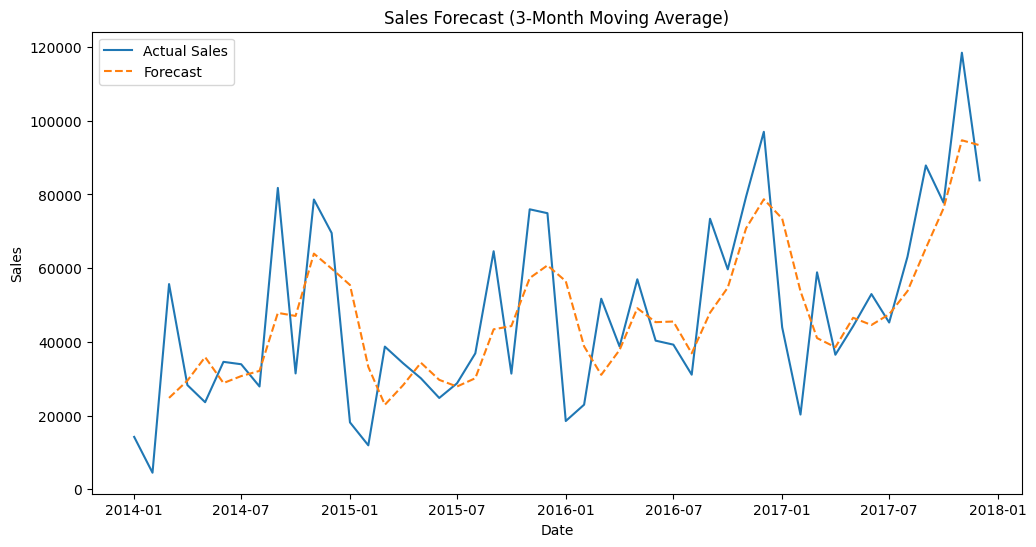

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(forecast_data["Date"], forecast_data["Sales"], label="Actual Sales")
plt.plot(forecast_data["Date"], forecast_data["Forecast"], label="Forecast", linestyle="--")

plt.title("Sales Forecast (3-Month Moving Average)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [56]:
report = f"""
AI-Generated Business Insights:

1. Total sales reached {round(total_sales,2)} with a profit of {round(total_profit,2)}.

2. The West region is the highest revenue contributor.

3. Technology category is the best performing segment in terms of sales.

4. Significant number of transactions ({loss_products.shape[0]}) are loss-making, indicating pricing or discount issues.

5. Discount analysis shows that higher discounts reduce profitability.

6. Consumer segment generates the highest revenue.

7. Bookcases are the worst-performing sub-category, while Copiers generate the highest profit.

8. RFM analysis shows that most customers fall under the Regular segment, contributing the highest revenue, while VIP customers are limited.

9. Anomaly detection identified unusual spikes and drops in sales, especially during seasonal periods.

10. Forecasting indicates an overall upward trend in sales with fluctuations.

Conclusion:
The business shows strong growth potential, but profitability can be improved by optimizing discount strategies and focusing on high-performing products and customer segments.
"""

print(report)


AI-Generated Business Insights:

1. Total sales reached 2297200.86 with a profit of 286397.02.

2. The West region is the highest revenue contributor.

3. Technology category is the best performing segment in terms of sales.

4. Significant number of transactions (1871) are loss-making, indicating pricing or discount issues.

5. Discount analysis shows that higher discounts reduce profitability.

6. Consumer segment generates the highest revenue.

7. Bookcases are the worst-performing sub-category, while Copiers generate the highest profit.

8. RFM analysis shows that most customers fall under the Regular segment, contributing the highest revenue, while VIP customers are limited.

9. Anomaly detection identified unusual spikes and drops in sales, especially during seasonal periods.

10. Forecasting indicates an overall upward trend in sales with fluctuations.

Conclusion:
The business shows strong growth potential, but profitability can be improved by optimizing discount strategies an

In [1]:
import urllib.parse
from sqlalchemy import create_engine

# 1. Setup your details
username = "postgres"
password = "Jai@1234"
host = "localhost"
port = "5432"
database = "superstore_project"

# 2. This part fixes the "@" symbol issue in your password
safe_password = urllib.parse.quote_plus(password)

# 3. Create the engine
engine = create_engine(f"postgresql+psycopg2://{username}:{safe_password}@{host}:{port}/{database}")

# 4. Test the connection
try:
    with engine.connect() as connection:
        print("✅ Success! You are connected to the database.")
except Exception as e:
    print(f"❌ Still failing. Error: {e}")

✅ Success! You are connected to the database.


In [5]:
# Choose a table name
table_name = "sales"

# This sends the data to PostgreSQL
# if_exists="replace" will overwrite the table if it already exists
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"✅ Data successfully loaded into table '{table_name}' in database '{database}'.")

✅ Data successfully loaded into table 'sales' in database 'superstore_project'.
